In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'

from joblib import Parallel, delayed

from scipy.special import iv
from scipy.optimize import curve_fit

In [2]:
import schwingerModel as sim

In [3]:
m = .2
a = 1
dimx = 32
dimt = 32
beta = 10
temp = sim.schwingerModel(metroSteps=20,beta=beta,dimx=dimx,dimt=dimt,aSpacing=a,fMass=m)

100%|██████████| 20/20 [02:07<00:00,  6.39s/it]


In [18]:
rhoBar = sim.analysis.getEffMassRhoBar(temp)
sim.analysis.get_integrated_autocorr_time_statistical(rhoBar,temp.metroSteps)

(np.float64(0.44544142687452143), np.float64(0.15430543662852958), 1)

In [94]:
gamma = np.array([[1j,0],[0,-1j]])
bIn = 1000
skp = 10
correl = sim.analysis.correlStats(temp, burnIn=bIn,autocorrSkip=skp,Gamma=gamma,includeDisc=False)
effectiveMass = sim.analysis.effectiveMassStats(temp, burnIn=bIn,autocorrSkip=skp,Gamma=gamma,includeDisc=False,coshExpr=True)

Text(0.5, 1.0, 'Correlation:  $N_t = 32$,$N_x=32$ $a=1$, $m=0.2$, $\\beta=10$, $\\Gamma=\\sigma_3$')

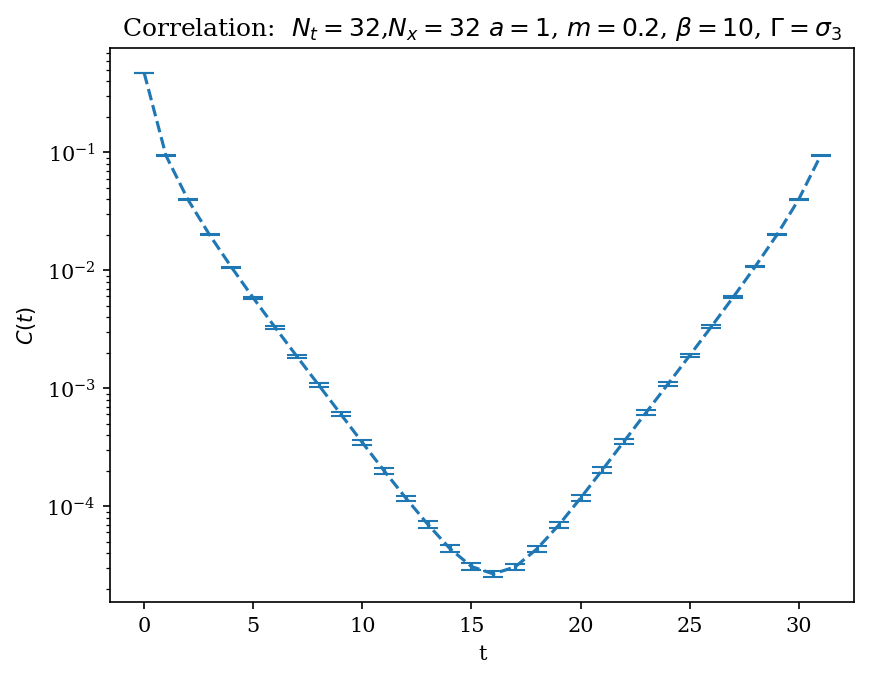

In [95]:
plt.figure(dpi=150)
plt.errorbar(x=np.arange(len(correl[0])),y=correl[0],yerr=correl[1].T,ls="--",capsize=5)
plt.semilogy()
plt.xlabel("t")
plt.ylabel(r"$C(t)$")
plt.title(rf"Correlation:  $N_t = {dimt}$,$N_x={dimx}$ $a={a}$, $m={m}$, $\beta={beta}$, $\Gamma=\sigma_3$")

Text(0.5, 1.0, 'Effective Mass: $N_t = 32$,$N_x=32$ $a=1$, $m=0.2$, $\\beta=10$, $\\Gamma=\\sigma_3$')

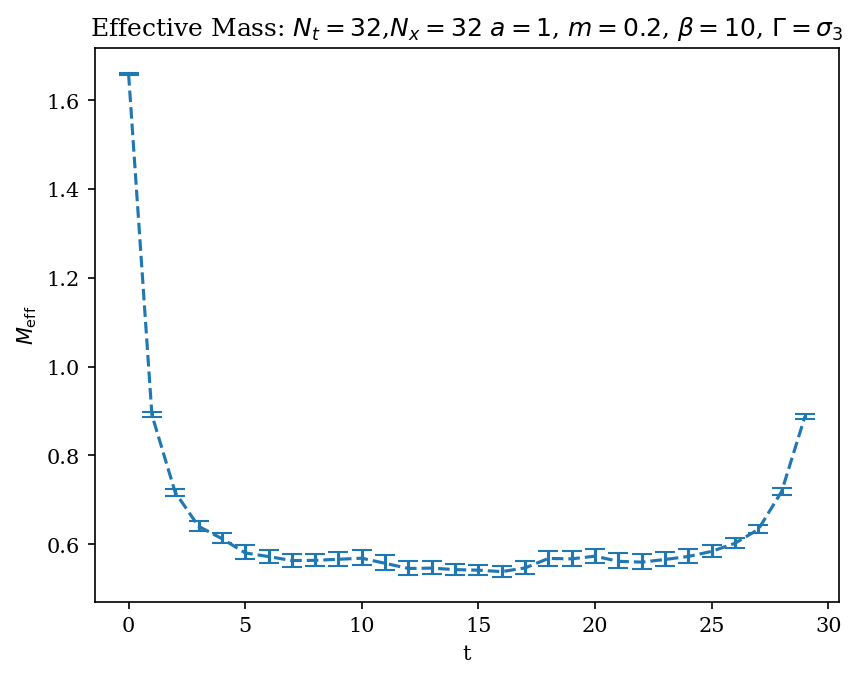

In [96]:
plt.figure(dpi=150)
plt.errorbar(x=np.arange(len(effectiveMass[0])),y=np.abs(effectiveMass[0]),yerr=effectiveMass[1].T,ls="--",capsize=5)
plt.xlabel("t")
plt.ylabel(r"$M_{\text{eff}}$")
plt.title(rf"Effective Mass: $N_t = {dimt}$,$N_x={dimx}$ $a={a}$, $m={m}$, $\beta={beta}$, $\Gamma=\sigma_3$")

In [39]:
# testBetas = np.linspace(.5,5,8)

# models = Parallel(n_jobs=14)(delayed(schwingerModel)(metroSteps=1000,beta=b,dimx=8,dimt=8,aSpacing=1,fMass=.1) for b in testBetas)

# spStats = np.array([m.plaqStats(100) for m in models])

In [40]:
# plt.figure(dpi=250)
# plt.errorbar(testBetas,spStats[:,0],yerr=spStats[:,1],capsize=3,fmt=".")
# plt.xlabel(r"$\beta$")
# plt.ylabel(r"$\langle \cos \theta_P \rangle$")

# plt.plot(testBetas,iv(1,testBetas)/iv(0,testBetas),label=r"Exact (no $\psi$): $\frac{I_1(\beta)}{I_0(\beta)}$")
# plt.legend()